# Homework 12: Time Series Analysis
### Abdullah Junejo (07154)

In [1]:
import math
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.simplefilter("ignore")
plt.style.use('fivethirtyeight')
import pandas as pd
import statsmodels.api as sm
import matplotlib
from pylab import rcParams
matplotlib.rcParams.update({'axes.labelsize': 14, 'xtick.labelsize': 12, 
                            'ytick.labelsize': 12, 'text.color': 'k'})
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
#reading the data
df = pd.read_csv("karachi-weather-2021-2023.csv", parse_dates=['datetime'])
df = df.set_index('datetime')
df.head()


,temp
datetime,
2021-01-01,15.0
2021-01-02,15.4
2021-01-03,15.6
2021-01-04,16.3
2021-01-05,17.1


# Q1,2

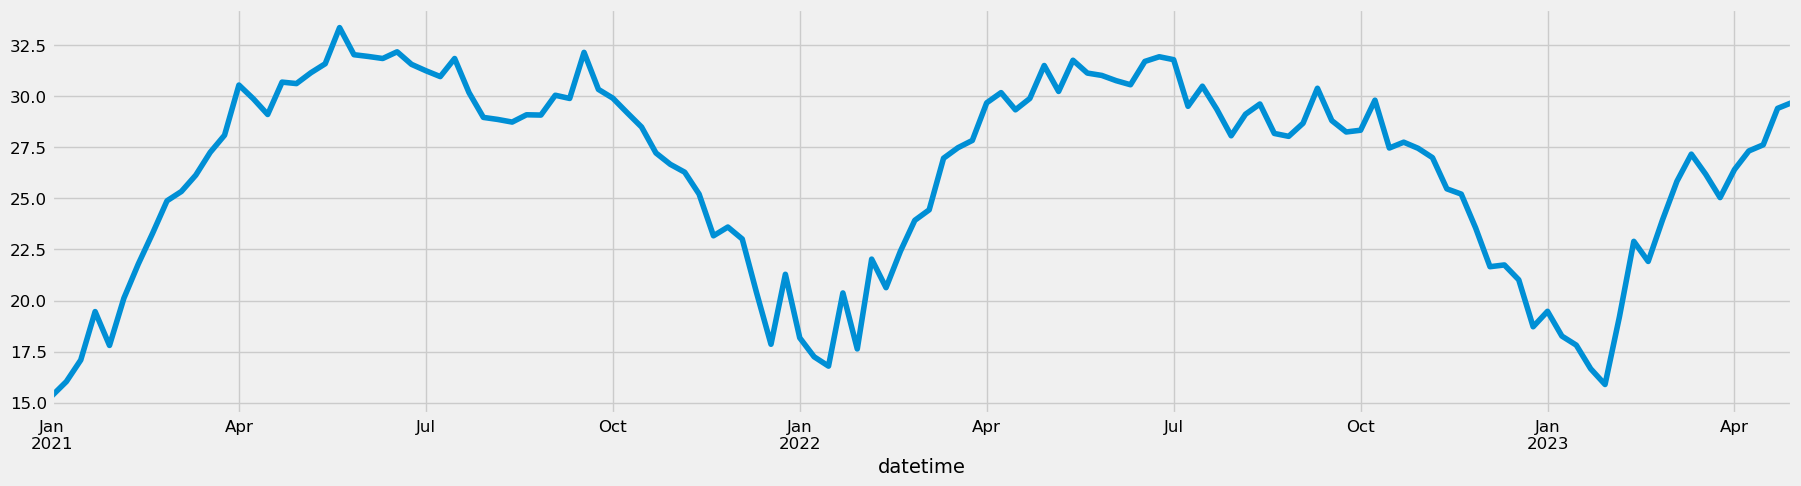

In [2]:
y = df['temp'].resample('W').mean()
y.plot(figsize=(20, 5))
plt.show()

### The graph clearly shows a reoccurring cyclical pattern most likely corresponding to seasonal changes throughout the year, with peaks indicating hotter months and dips indicating cooler months.

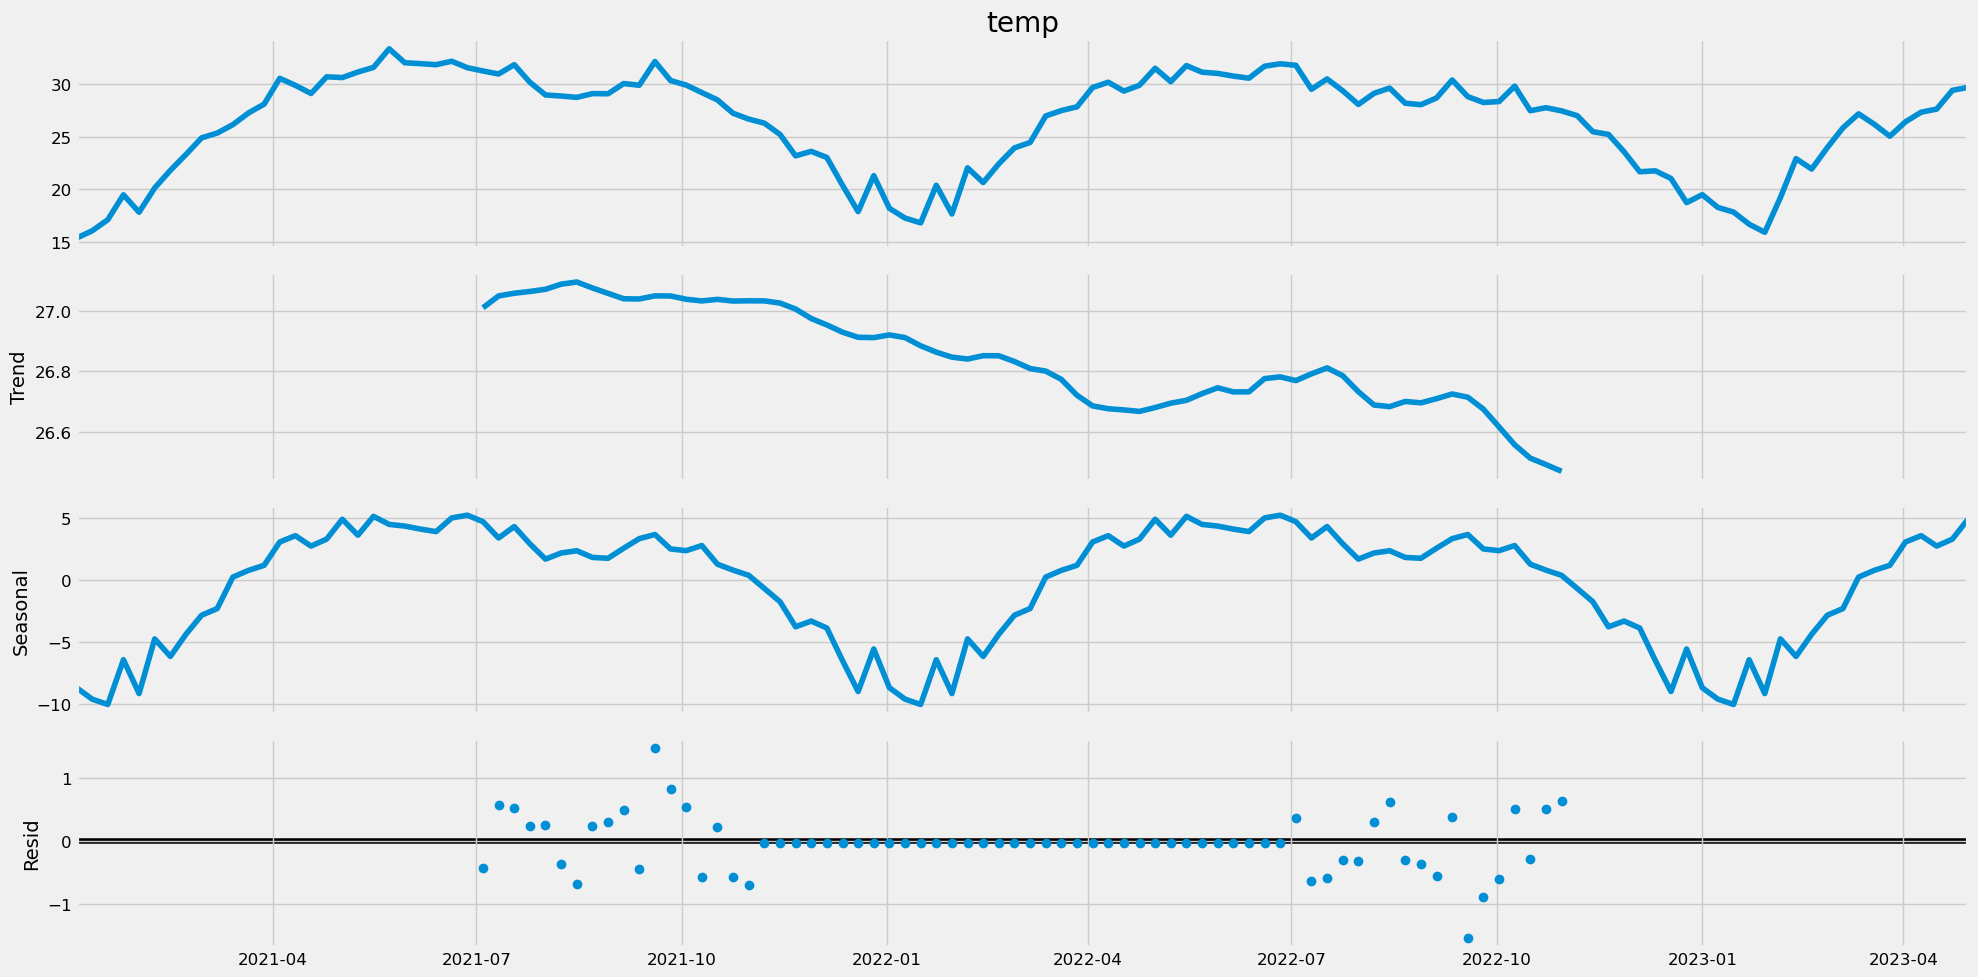

In [3]:
#Decomposition for seperating
decomposition = sm.tsa.seasonal_decompose(y, model='additive')
rcParams['figure.figsize'] = 20, 10
decomposition.plot()
plt.show()

### The decomposition has highlighted the predictable seasonal temperature fluctuations that could be linked to Karachi's specific climate patterns. The seasonal component appears to have a yearly repeating pattern, implying yearly seasonality. The lack of a strong trend suggests that temperatures haven't changed significantly over this time period, aside from their seasonal cycle. We can think of Climate Change/Global Warming as having had little impact on Karachi. The residual plot shows that the trend and seasonal components have successfully captured the majority of the time series' systematic structure, indicating that the model is a good fit for predicting Karachi's weather.


# Q3

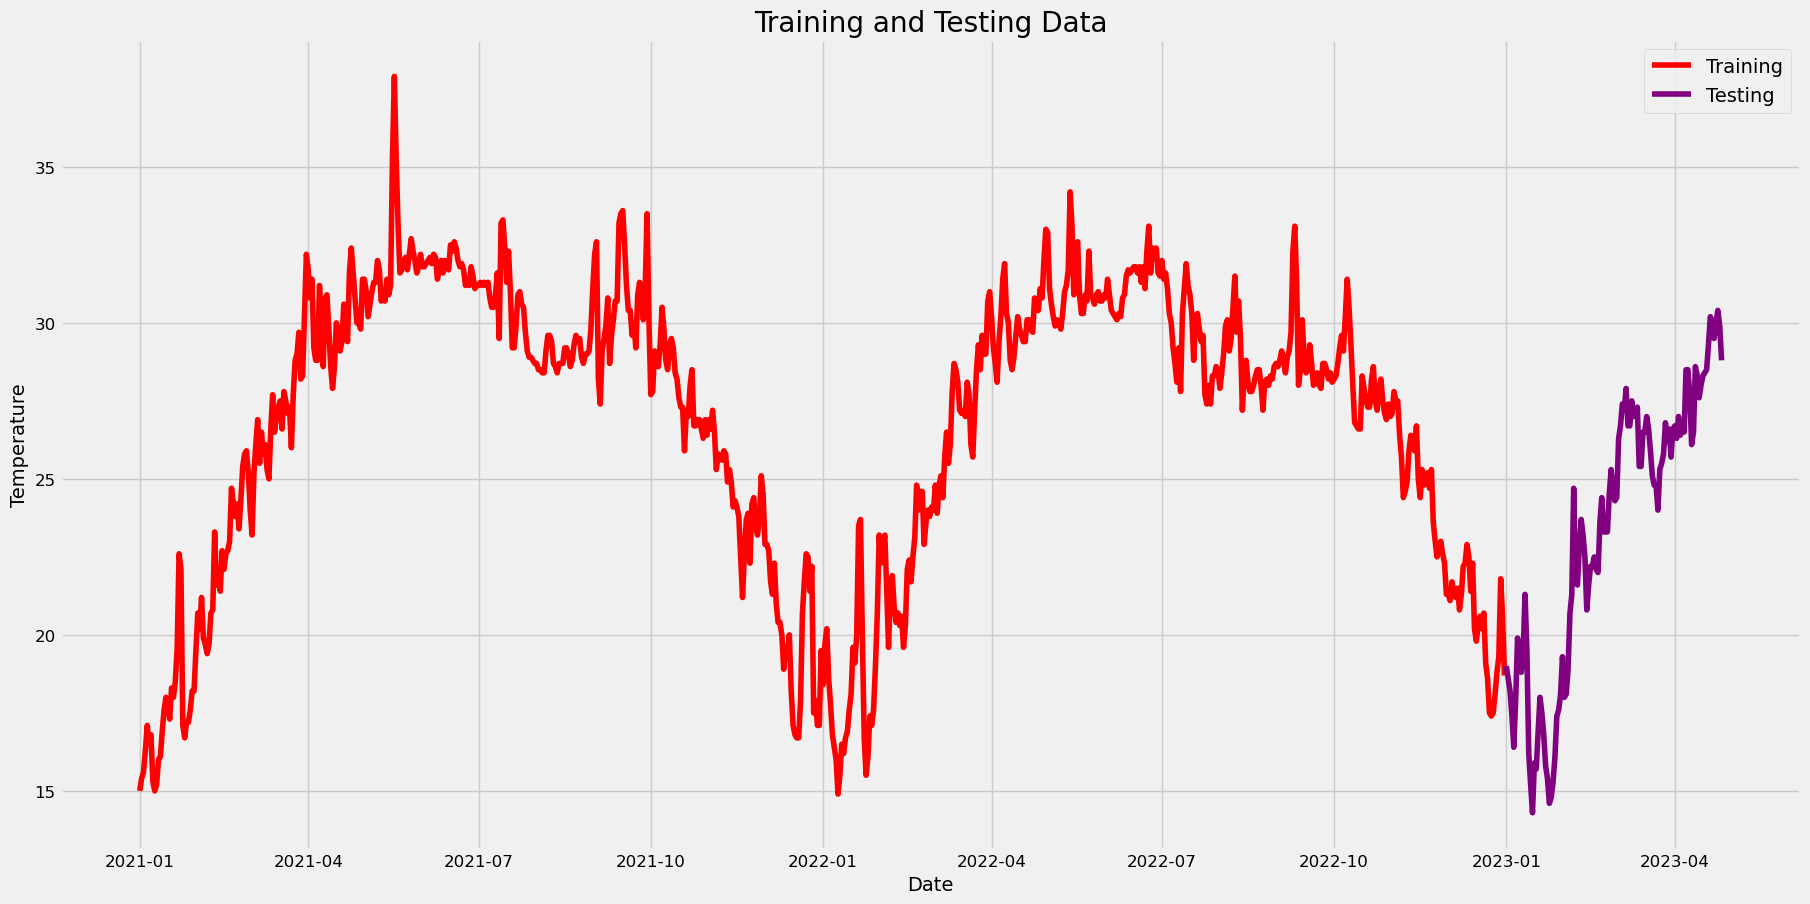

In [4]:
#splitting data
training_Data = df[df.index < pd.to_datetime('2023-01-01', format='%Y-%m-%d')]
testing_Data = df[df.index >= pd.to_datetime('2023-01-01', format='%Y-%m-%d')]

#plotting
plt.plot(training_Data, label='Training', color='red')
plt.plot(testing_Data, label='Testing', color='purple')

plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Training and Testing Data')
plt.legend()
plt.show()

#### The training data is depicted by the red line, charting weather temperatures for the years 2021 and 2022, while the purple line illustrates the testing data, which includes temperatures for the year 2023. The visualization clearly demonstrates a consistent cyclic wave temperature trend.

# Q4

C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self.

C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self.

Optimal RMSE: 2.983746635071503 Optimal Parameters: (1, 0, 1)


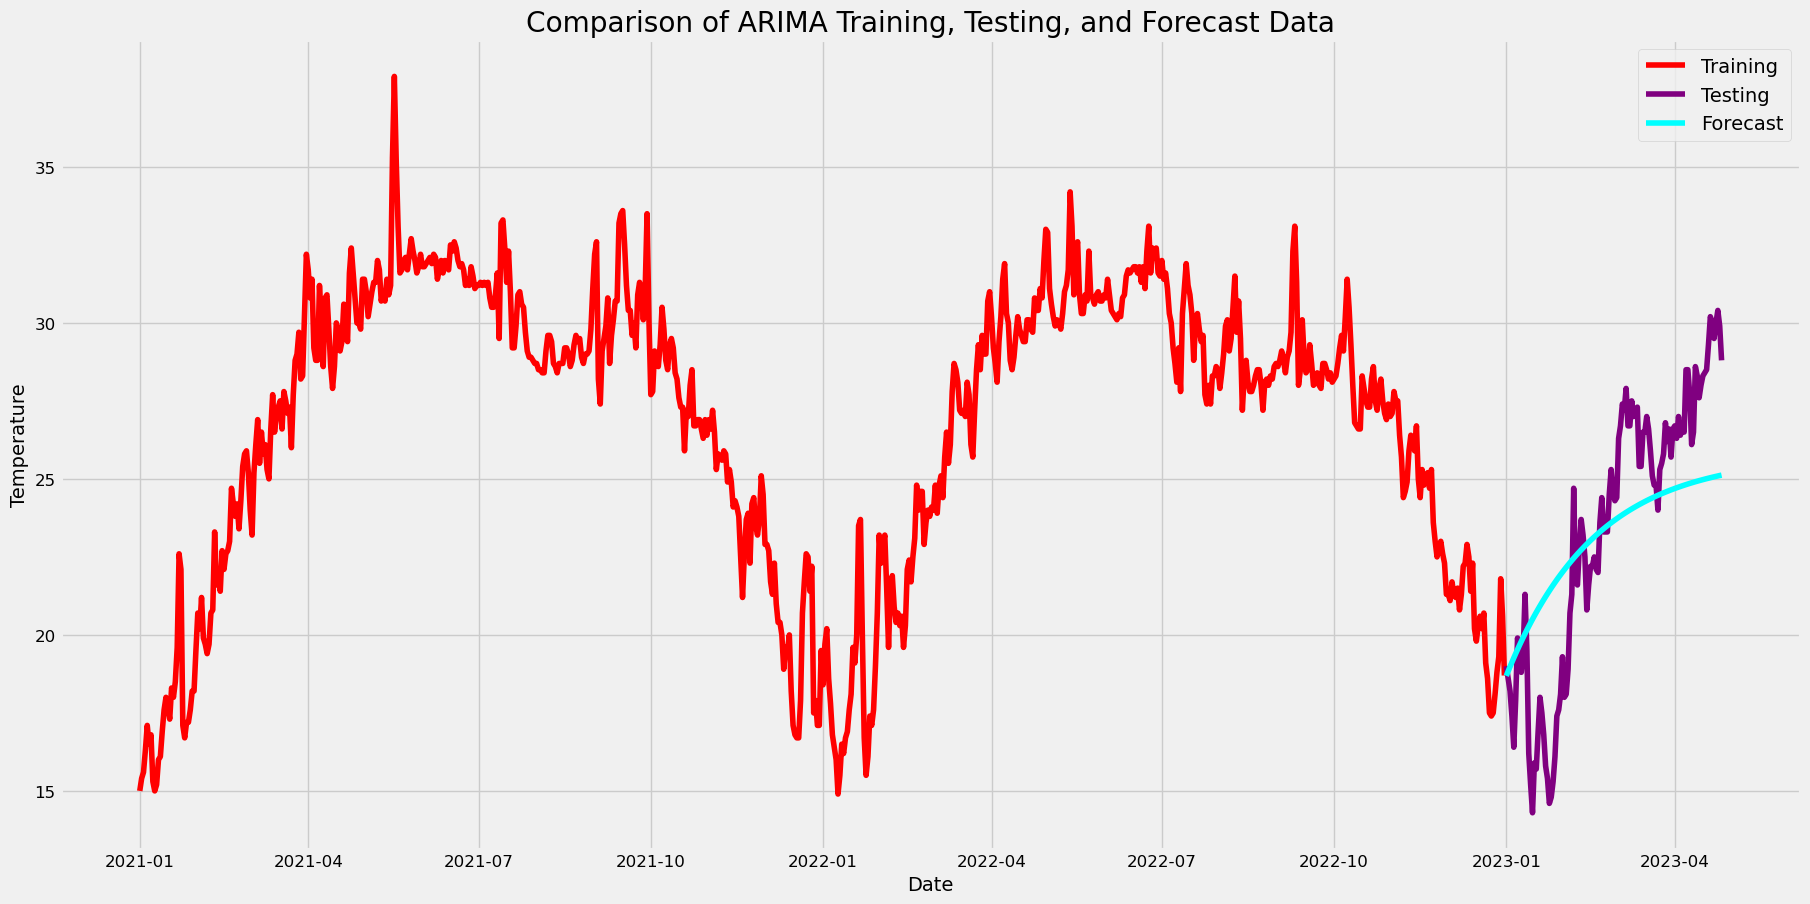

In [8]:
#Function for Arima Model
def ArimaModelOptimal(p, d, q, training, testing):
    model_arima = ARIMA(training, order=(p, d, q))
    model_fit = model_arima.fit()

    #Forecasting
    predictions = model_fit.get_forecast(steps=len(testing))
    pred_conf = predictions.conf_int(alpha=0.05)
    pred_conf['Forecast'] = model_fit.predict(start=pred_conf.index[0], end=pred_conf.index[-1])
    pred_conf.index = testing.index
    forecast = pred_conf['Forecast']
    rmse_value = np.sqrt(mean_squared_error(testing, forecast)) #RMSE calculation
    return rmse_value, forecast

#Initialize best RMSE as Infinity aka very high number
optimal_rmse = float('inf')

#Values to iterate for p, d, q
values_range = [0, 1, 2]

#Generating all combinations for p, d, q
parameter_combinations = list(itertools.product(values_range, repeat=3))

#Searching for the optimal combination
for combination in parameter_combinations:
    rmse, forecasted_values = ArimaModelOptimal(p=combination[0], d=combination[1], q=combination[2], training=training_Data, testing=testing_Data)

    #Updating
    if rmse < optimal_rmse:
        optimal_rmse = rmse
        optimal_forecast = forecasted_values
        optimal_params = combination

print('Optimal RMSE:', optimal_rmse, 'Optimal Parameters:', optimal_params)

#Ploting
plt.plot(training_Data, label='Training', color='red')
plt.plot(testing_Data, label='Testing', color='purple')
plt.plot(optimal_forecast, label='Forecast', color='cyan')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Comparison of ARIMA Training, Testing, and Forecast Data')
plt.legend()
plt.show()


### With the exception of few outliers, the predicted results look fairly accurate and in our printed statement, the Optimal RMSE for the model is almost 3.00. This implies that the model is a good fit for the data.

# Q5,6

C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(0, 0, 0)x(0, 0, 0, 52) - AIC:6891.386679959134
SARIMA(0, 0, 1)x(0, 0, 1, 52) - AIC:4806.471521879381


C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(0, 1, 0)x(0, 1, 0, 52) - AIC:2331.2681429748873


C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(1, 1, 0)x(1, 1, 0, 52) - AIC:2003.2464035995495


C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(1, 1, 1)x(1, 1, 1, 52) - AIC:1854.2518305591918


C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


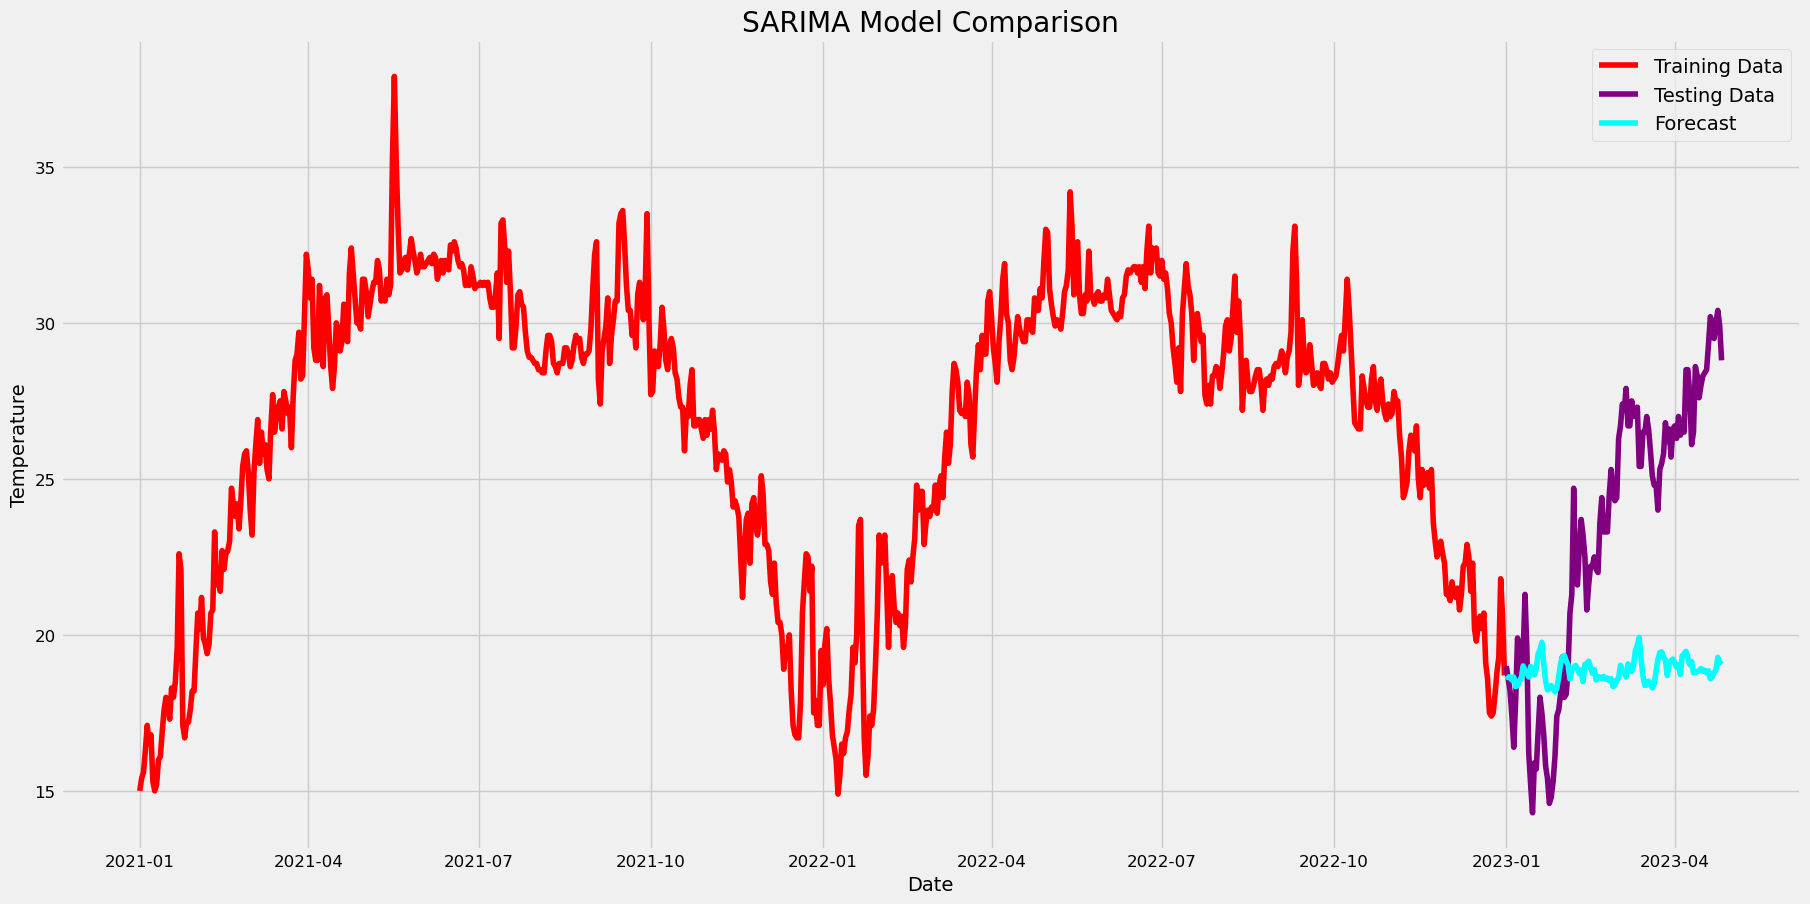

Forecast RMSE: 6.267886413975005


In [6]:
#Setting up the parameter ranges as stated in the question.
p = d = q = range(0, 2)
seasonal_periods = 52
seasonal_combinations = [(x[0], x[1], x[2], seasonal_periods) for x in list(itertools.product(p, d, q))]

#Searching for the best parameters based on AIC
for combination in seasonal_combinations:
    try:
        model = SARIMAX(training_Data,
                        order=combination[:3],
                        seasonal_order=combination,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit()
        
        print('SARIMA{}x{} - AIC:{}'.format(combination[:3], combination, model_fit.aic))
    except:
        continue

#Fitting the SARIMA model with the chosen parameters
sarima_model = SARIMAX(training_Data, order=(0, 1, 1), seasonal_order=(1, 1, 1, seasonal_periods))
sarima_results = sarima_model.fit()

#Forecasting
predictions = sarima_results.get_forecast(steps=len(testing_Data))
predictions_conf_int = predictions.conf_int(alpha=0.05)
predictions_conf_int['Forecast'] = sarima_results.predict(start=predictions_conf_int.index[0], end=predictions_conf_int.index[-1])
predictions_conf_int.index = testing_Data.index
forecast_values = predictions_conf_int['Forecast']

#Plotting
plt.plot(training_Data, label='Training Data', color='red')
plt.plot(testing_Data, label='Testing Data', color='purple')
plt.plot(forecast_values, label='Forecast', color='cyan')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('SARIMA Model Comparison')
plt.legend()
plt.show()

# Calculating the RMSE
forecast_rmse = np.sqrt(mean_squared_error(testing_Data, forecast_values))
print('Forecast RMSE:', forecast_rmse)

### This model's Root Mean Square Error (RMSE) is approximately 6.2, which exceeds the RMSE observed in the previous model, indicating a less precise fit to the data. Observations from the forecast show a clear difference between the predicted and actual values, highlighting the model's limited ability to accurately capture the dataset's trend and seasonal fluctuations.


### The best ARIMAX model parameters found are (1,0,1), with an RMSE of 3.00. The optimal parameters for the SARIMAX model, on the other hand, are (1,1,1), with an RMSE of 6.2. Clearly, the ARIMA model outperforms the SARIMA model in terms of RMSE and overall accuracy. As a result, the ARIMA model outperforms its SARIMA counterpart in terms of dataset fit.


# Q7,8

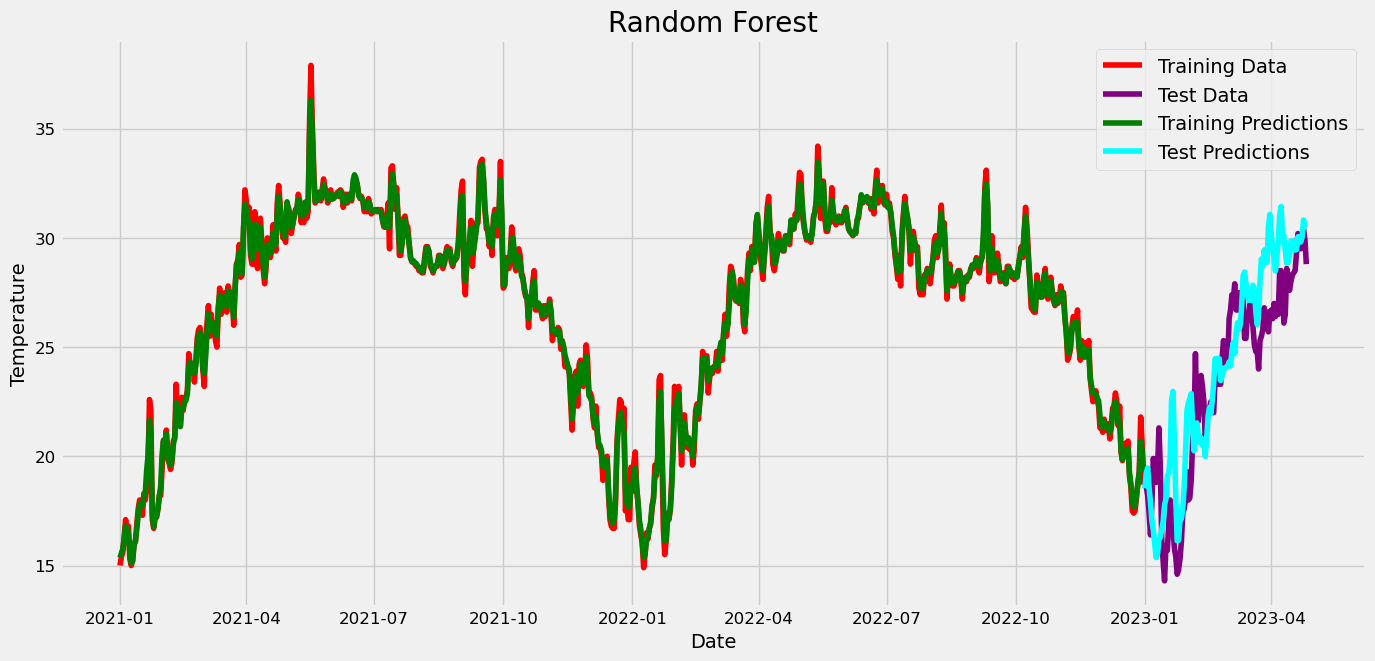

Random Forest RMSE: 2.3338666026500965


In [11]:
#Extracting date components as features for the training and test sets
X_train = np.array([[x.day, x.month, x.year] for x in training_Data.index])
y_train = training_Data.values.ravel()  # Flattening the array

X_test = np.array([[x.day, x.month, x.year] for x in testing_Data.index])
y_test = testing_Data.values.ravel()  # Flattening the array

#Initialize and fit the Random Forest model
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, y_train)

#Make predictions on both the training and test data
train_preds = rf_regressor.predict(X_train)
test_preds = rf_regressor.predict(X_test)

#Plotting the training, test, and predicted data
plt.figure(figsize=(15, 7))  # Setting the figure size
plt.plot(training_Data.index, y_train, label='Training Data', color='red')
plt.plot(testing_Data.index, y_test, label='Test Data', color='purple')
plt.plot(training_Data.index, train_preds, label='Training Predictions', color='green')
plt.plot(testing_Data.index, test_preds, label='Test Predictions', color='cyan')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Random Forest')
plt.legend()
plt.show()

# Compute the RMSE for the Random Forest model's predictions
rf_rmse = math.sqrt(mean_squared_error(y_test, test_preds))
print('Random Forest RMSE:', rf_rmse)


### The Random Forest machine learning approach produced the best RMSE of 2.3, outperforming all other models. The forecasts closely mimic the actual temperature readings and capture both trend and seasonal variations in time series data. 

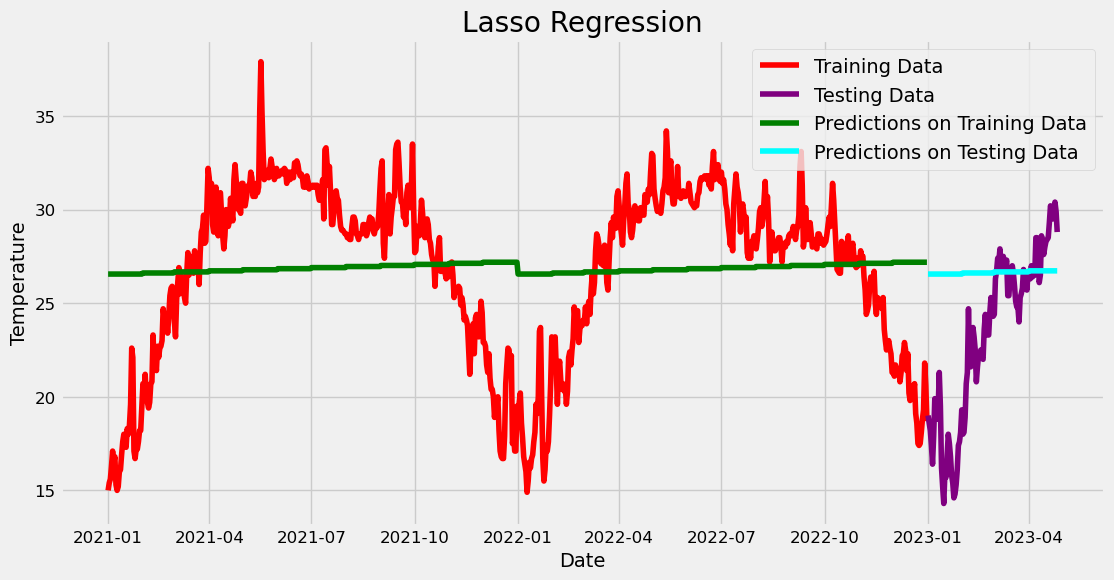

Lasso Model RMSE: 5.469346727334808


In [20]:
#Initialize
lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

#Forecasting
lasso_predictions_train = lasso_model.predict(X_train)
lasso_predictions_test = lasso_model.predict(X_test)

#Visualize
plt.figure(figsize=(12, 6))
plt.plot(training_Data.index, y_train, label='Training Data', color='red')
plt.plot(testing_Data.index, y_test, label='Testing Data', color='purple')
plt.plot(training_Data.index, lasso_predictions_train, label='Predictions on Training Data', color='green')
plt.plot(testing_Data.index, lasso_predictions_test, label='Predictions on Testing Data', color='cyan')
plt.title('Lasso Regression')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

#Calculating Root Mean Square
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions_test))
print('Lasso Model RMSE:', lasso_rmse)


### The Lasso regression model yields an RMSE of 5.4, ranking it second highest in terms of error among the four models tested, suggesting a suboptimal fit for the data. It almost looks like a line of best fit that far deviates from the actual data.

### The machine learning approach provided by the Random Forest Regressor proved superior for this particular dataset, offering a balance of complexity and predictive performance. Despite its simplicity and regularisation capabilities, the Lasso Regressor was not as effective, most likely because it could not account for the data's time series nature without the creation of additional temporal features. The ARIMA model, which assumes a linear relationship and captures time-dependence, outperformed SARIMA, possibly due to the lack of strong seasonal components in the data.




# Q9,10,11

C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\abdul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


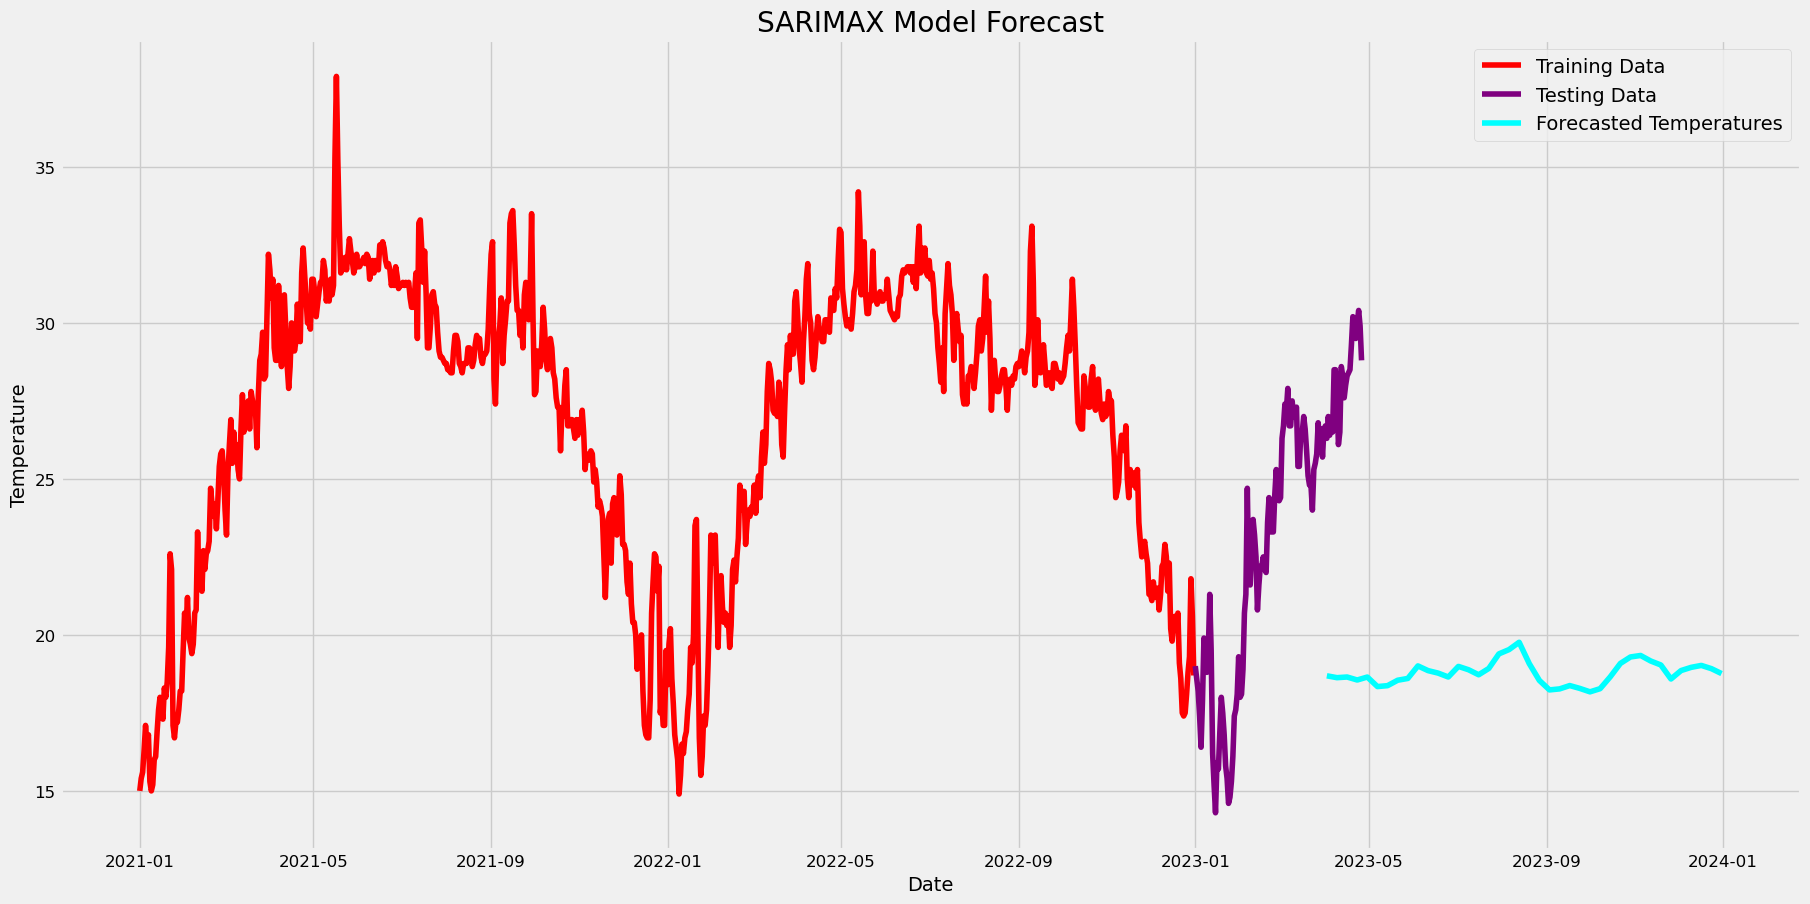

In [29]:
#Date Range
future_dates = pd.date_range(start='2023-04-01', end='2023-12-31', freq='W')

#Fit the SARIMA model
optimal_sarimax_model = SARIMAX(training_Data, order=(0,1,1), seasonal_order=(1,1,1,52))
fitted_sarimax_model = optimal_sarimax_model.fit()

#Forecasting
temperature_forecast = fitted_sarimax_model.get_forecast(steps=len(future_dates))
forecast_confidence_intervals = temperature_forecast.conf_int(alpha=0.05)

forecast_confidence_intervals['Forecasted_Temperatures'] = fitted_sarimax_model.predict(
    start=forecast_confidence_intervals.index[0], 
    end=forecast_confidence_intervals.index[-1])

forecast_confidence_intervals.index = future_dates
forecasted_temperatures = forecast_confidence_intervals['Forecasted_Temperatures']

#Plotting
plt.plot(training_Data, label='Training Data', color='red')
plt.plot(testing_Data, label='Testing Data', color='purple')
plt.plot(forecasted_temperatures, label='Forecasted Temperatures', color='cyan')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('SARIMAX Model Forecast')
plt.legend()
plt.show()




### The SARIMAX forecast of nearly constant temperatures does not correspond to Karachi's historical summer highs, which typically range between 30 and 40 degrees Celsius.

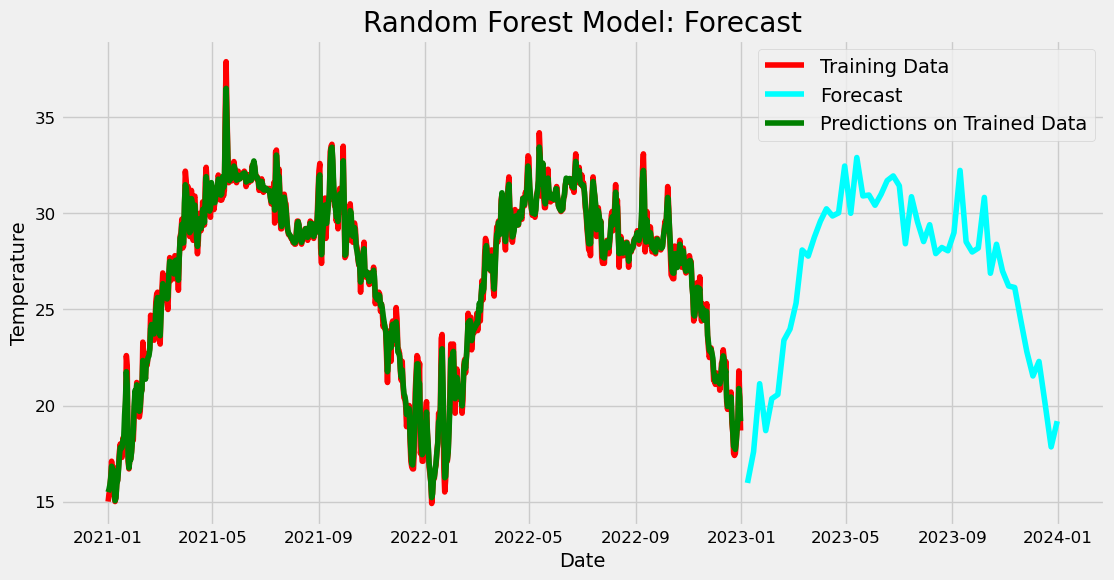

In [35]:
#Date Range:
future_dates_rf = pd.date_range(start='01-04-2023', end='31-12-2023', freq='W')

future_months = [date.month for date in future_dates_rf]
future_years = [date.year for date in future_dates_rf]
future_days = [date.day for date in future_dates_rf]

#Forecasting
X_future_rf = np.array([future_days, future_months, future_years]).T
training_months = [date.month for date in training_Data.index]
training_years = [date.year for date in training_Data.index]
training_days = [date.day for date in training_Data.index]
X_train_rf = np.array([training_days, training_months, training_years]).T
random_forest_model = RandomForestRegressor()
random_forest_model.fit(X_train_rf, training_Data.values.ravel())
historical_predictions_rf = random_forest_model.predict(X_train)
future_predictions_rf = random_forest_model.predict(X_future_rf)

#Plotting
plt.figure(figsize=(12, 6))
plt.plot(training_Data.index, training_Data.values, label='Training Data', color='Red')
plt.plot(future_dates_rf, future_predictions_rf, label='Forecast', color='Cyan')
plt.plot(training_Data.index, historical_predictions_rf, label='Predictions on Trained Data', color='Green')
plt.title('Random Forest Model: Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()


###  The Random Forest model accurately predicts summer temperatures in Karachi, closely mirroring historical trends with forecasts of 30 to 35 degrees Celsius.

### The SARIMAX model fails to account for seasonal temperature variations. This is evident from the forecast plot, where the model's projections flatline, predicting temperatures to hover around 17 to 19 degrees Celsius, which is different from Karachi's typical 30 to 40-degree range.The Random Forest model corresponding plot, on the other hand, shows how well this model's forecasts align with actual temperature fluctuations (30 to 35 degrees Celsius range). This demonstrates the Random Forest model's ability to recognise and adapt to the data's characteristic patterns.
